# Dzien 2 / Krok 2: Feature Engineering i model bazowy

**Input:** `checkpoints/01_merged.parquet`
**Output:** `checkpoints/02_train.parquet`, `checkpoints/02_test.parquet`

Budujemy cechy, trenujemy prosty model bazowy i oceniamy go.
Na koncu tego kroku: pierwsze zadanie projektowe (Kolb).

In [14]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_parquet("checkpoints/01_merged.parquet")
print(f"Zaladowano: {df.shape}")
print(f"Target rate: {df['is_bad_experience'].mean():.3f}")

Zaladowano: (95832, 27)
Target rate: 0.098


## Trend i sezonowosc wolumenu zamowien

Zanim zbudujemy cechy, zobaczmy jak wyglada wolumen zamowien w czasie.
Z tego szeregu wyciagniemy dwa sygnaly, ktore wejda do modelu jako cechy.

Intuicja:
- **Trend**: platforma rosnie - wiecej zamowien = wieksze obciazenie logistyki = potencjalnie wiecej opoznien
- **Sezonowosc**: niektore miesiace sa histocznie wyzsze (np. Black Friday, swieta) - to zmienia profil ryzyka

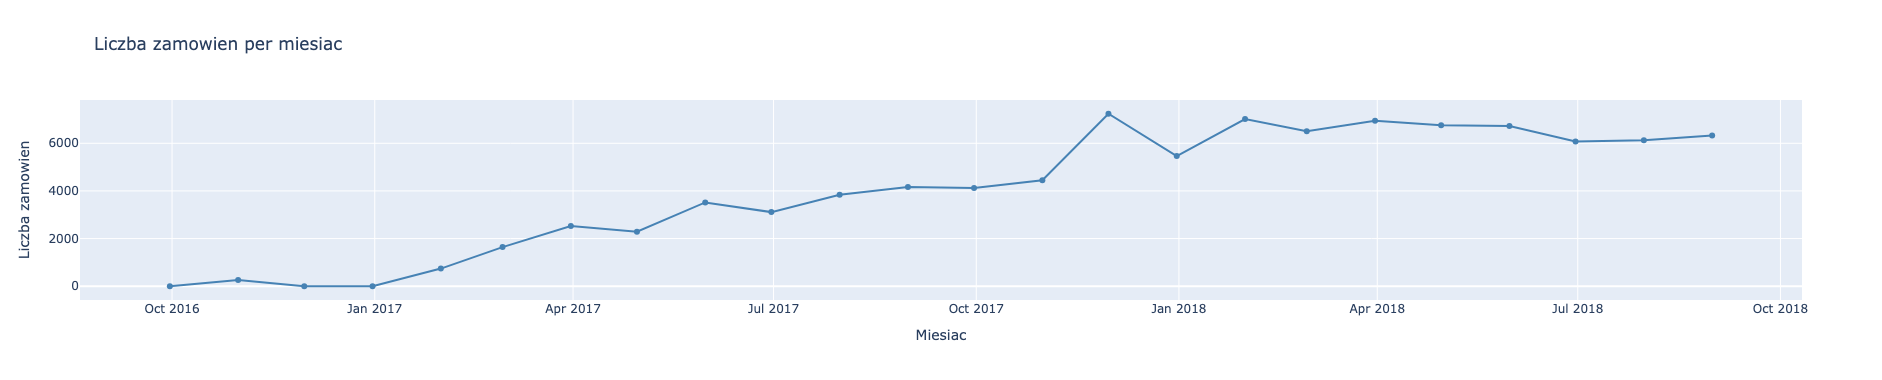

Liczba miesiecy: 24
Min: 2016-09-30  Max: 2018-08-31


In [15]:
# Wolumen zamowien per miesiac
df_monthly = (df.set_index("order_purchase_timestamp")
               .resample("ME")["order_id"]
               .count()
               .rename("order_volume"))

fig = go.Figure(go.Scatter(x=df_monthly.index, y=df_monthly.values,
                           mode="lines+markers", line=dict(color="steelblue", width=2)))
fig.update_layout(title="Liczba zamowien per miesiac",
                  xaxis_title="Miesiac", yaxis_title="Liczba zamowien", height=380)
fig.show()

print(f"Liczba miesiecy: {len(df_monthly)}")
print(f"Min: {df_monthly.index.min().date()}  Max: {df_monthly.index.max().date()}")

### Dekompozycja: trend + sezonowosc + reszta

Uzywamy `seasonal_decompose` z biblioteki statsmodels (ten sam algorytm co w notebooku budulcowym).

Krok po kroku:
1. Trend - srednia ruchoma z oknem 12 miesiecy (wygladza krotkoterminowe wahania)
2. Sezonowosc - srednie odchylenie od trendu per pozycja w cyklu (miesiac 1-12)
3. Reszta - to czego trend i sezon nie wyjasniaja

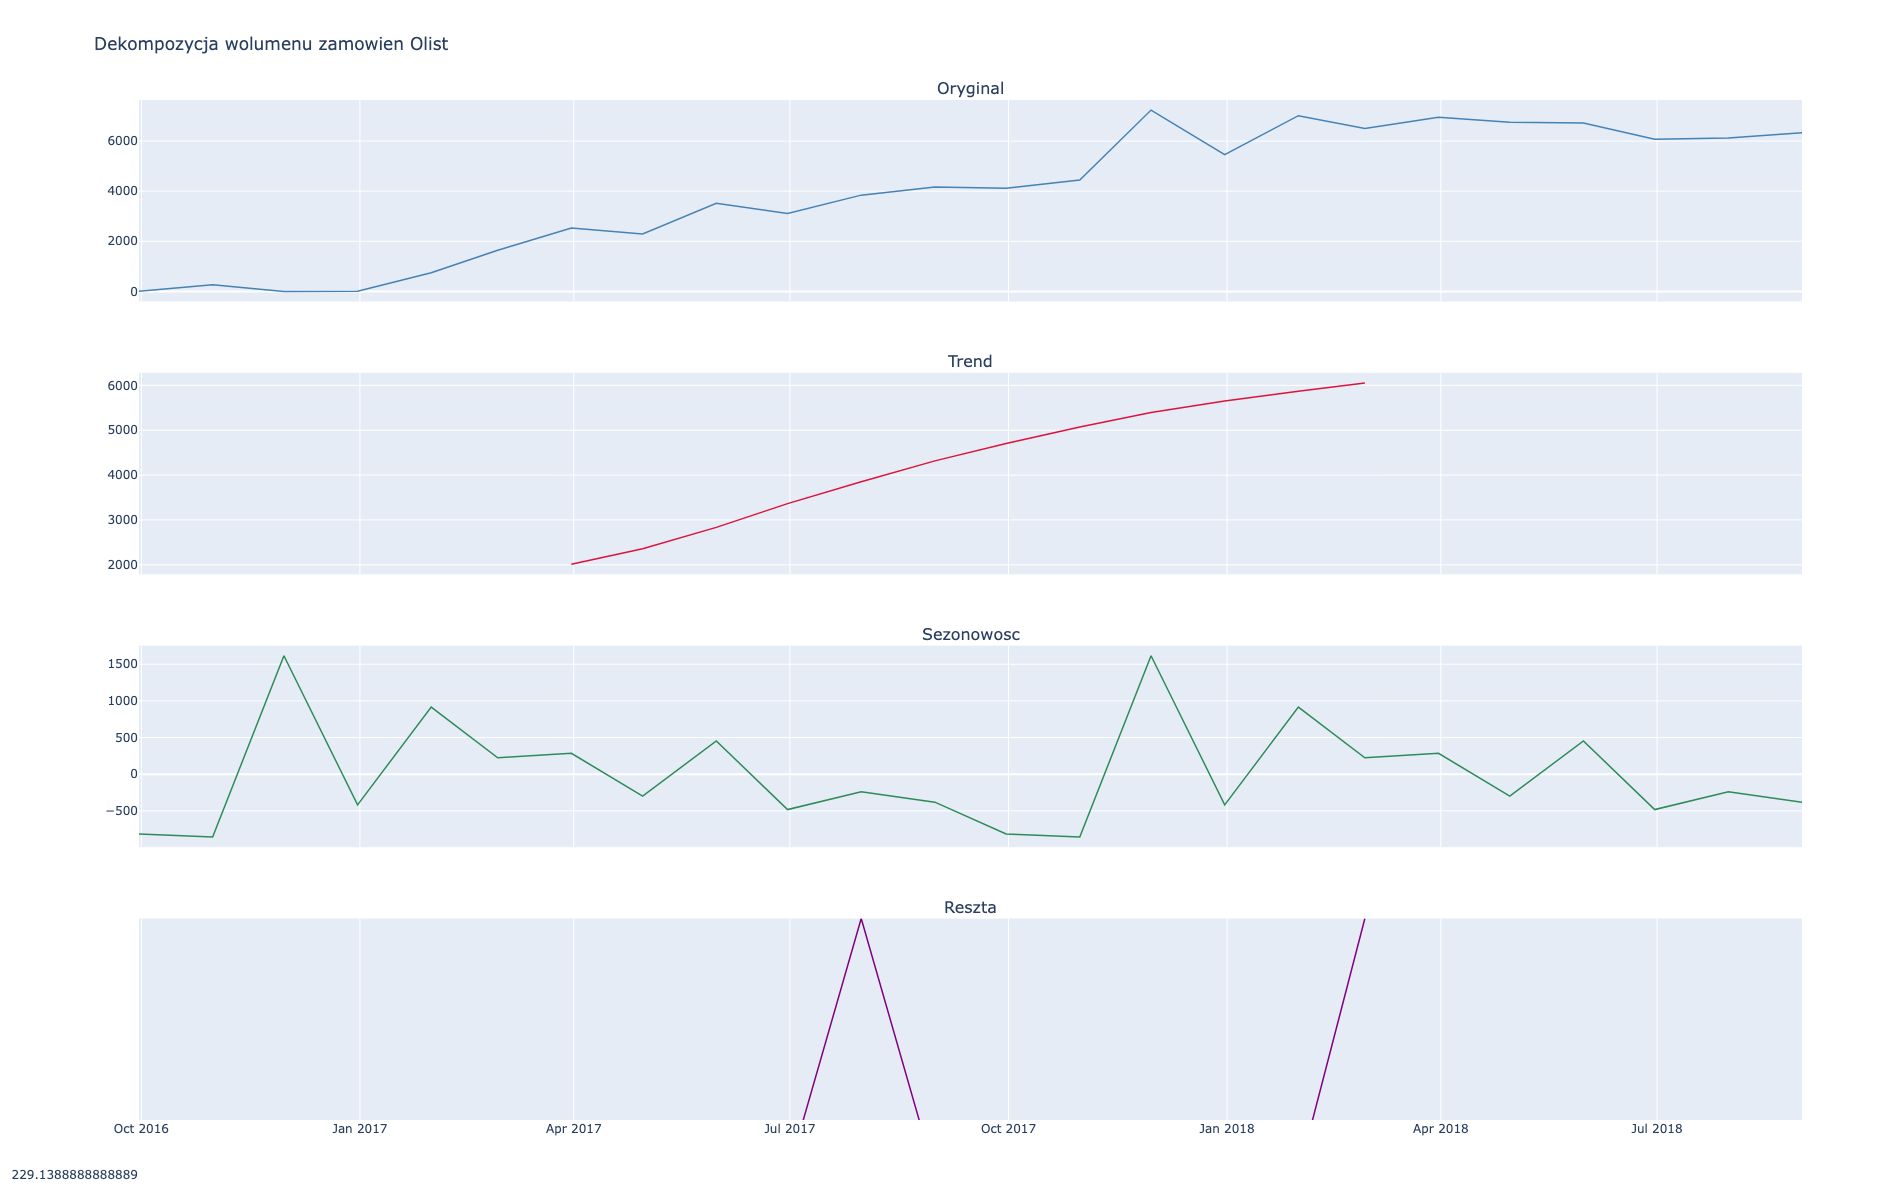

In [3]:
result = seasonal_decompose(df_monthly, model="additive", period=12)

fig = make_subplots(rows=4, cols=1,
                    subplot_titles=["Oryginal", "Trend", "Sezonowosc", "Reszta"],
                    shared_xaxes=True, vertical_spacing=0.07)

components = [
    (df_monthly,       "steelblue"),
    (result.trend,     "crimson"),
    (result.seasonal,  "seagreen"),
    (result.resid,     "purple"),
]
for i, (series, color) in enumerate(components, start=1):
    fig.add_trace(go.Scatter(x=series.index, y=series.values, mode="lines",
                             line=dict(color=color, width=1.5)), row=i, col=1)

fig.update_layout(height=1200, showlegend=False,
                  title="Dekompozycja wolumenu zamowien Olist")
fig.show()

### Mapowanie komponentow na zamowienia

Kazde zamowienie dostaje wartosc trendu i sezonowosci z miesiaca, w ktorym zostalo zlozone.
Trend bedzie mial NaN na krawędziach (pierwsze i ostatnie 6 miesiecy) - interpolujemy liniowo.

In [4]:
# Buduj lookup: okres (rok-miesiac) -> (trend, seasonal)
df_decomp = pd.DataFrame({
    "volume_trend":    result.trend.interpolate(method="linear", limit_direction="both"),
    "volume_seasonal": result.seasonal,
}, index=df_monthly.index)
df_decomp.index = df_decomp.index.to_period("M")

# Mapuj na kazde zamowienie
df["_period"] = df["order_purchase_timestamp"].dt.to_period("M")
df["volume_trend"]    = df["_period"].map(df_decomp["volume_trend"])
df["volume_seasonal"] = df["_period"].map(df_decomp["volume_seasonal"])
df = df.drop(columns=["_period"])

print(f"volume_trend NaN:    {df['volume_trend'].isna().sum()}")
print(f"volume_seasonal NaN: {df['volume_seasonal'].isna().sum()}")
print()
print(df[["order_purchase_timestamp", "volume_trend", "volume_seasonal"]].head(5))

volume_trend NaN:    0
volume_seasonal NaN: 0

  order_purchase_timestamp  volume_trend  volume_seasonal
0      2017-10-02 10:56:33   5074.000000      -857.138889
1      2018-07-24 20:41:37   6054.041667      -240.138889
2      2018-08-08 08:38:49   6054.041667      -381.138889
3      2017-11-18 19:28:06   5393.416667      1615.444444
4      2018-02-13 21:18:39   6054.041667       223.819444


## Budowa cech: build_features()

In [5]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    feat = df.copy()

    feat["estimated_delivery_days"] = (
        feat["order_estimated_delivery_date"] - feat["order_purchase_timestamp"]
    ).dt.days.clip(0, 120)

    # Czas od zlozenia zamowienia do zatwierdzenia platnosci.
    # Wolna akceptacja moze sygnalizowac problemy platnicze lub flagowanie przez
    # system antyfraduowy - takie zamowienia czesto maja potem trudniejsza realizacje.
    feat["approval_time_hours"] = (
        feat["order_approved_at"] - feat["order_purchase_timestamp"]
    ).dt.total_seconds().div(3600).clip(0, 48).fillna(24)

    feat["purchase_hour"]  = feat["order_purchase_timestamp"].dt.hour
    feat["purchase_dow"]   = feat["order_purchase_timestamp"].dt.dayofweek
    feat["purchase_month"] = feat["order_purchase_timestamp"].dt.month
    feat["is_weekend"]     = (feat["purchase_dow"] >= 5).astype(int)

    feat["price_log"]     = np.log1p(feat["price"])
    feat["freight_ratio"] = feat["freight_value"] / feat["price"].clip(lower=1)

    feat["payment_installments"] = feat["payment_installments"].fillna(0)
    feat["is_installment"]       = (feat["payment_installments"] > 1).astype(int)

    for col in ["payment_type", "product_category_name_english",
                "customer_state", "seller_state"]:
        le = LabelEncoder()
        feat[col + "_enc"] = le.fit_transform(
            feat[col].fillna("unknown").astype(str)
        )

    feat["product_weight_g"]   = feat["product_weight_g"].fillna(
                                     feat["product_weight_g"].median())
    feat["product_photos_qty"] = feat["product_photos_qty"].fillna(1)

    return feat

df_feat = build_features(df)
print(f"Cechy zbudowane: {df_feat.shape}")

Cechy zbudowane: (95832, 42)


In [6]:
FEATURE_COLS = [
    # Czas
    "estimated_delivery_days", "approval_time_hours",
    "purchase_hour", "purchase_dow", "purchase_month", "is_weekend",
    # Trend i sezonowosc (z dekompozycji szeregu miesięcznego)
    "volume_trend", "volume_seasonal",
    # Produkt i platnosc
    "price_log", "freight_ratio",
    "items_count", "payment_installments", "is_installment",
    "product_weight_g", "product_photos_qty",
    # Kategorie (zakodowane)
    "payment_type_enc", "product_category_name_english_enc",
    "customer_state_enc", "seller_state_enc",
]

print(f"Liczba cech: {len(FEATURE_COLS)}")
print()
for col in FEATURE_COLS:
    missing = df_feat[col].isna().sum()
    if missing > 0:
        print(f"  UWAGA brak: {col}: {missing}")
print("Braki: OK" if df_feat[FEATURE_COLS].isna().sum().sum() == 0 else "Sprawdz braki")

Liczba cech: 19

Braki: OK


## Train/test split

Uzywamy `stratify=y`, zeby zachowac proporcje klas w obu zbiorach.

Bez `stratify`: przy losowym podziale 80/20 moze sie zdarzyc, ze zbior testowy trafi na
wieksza lub mniejsza proporcje klasy 1 niz zbior treningowy. Na niezbalansowanych danych
(~10% klasy 1) to moze oznaczac np. 7% bad reviews w tescie i 11% w treningu - model
jest oceniany w innych warunkach niz treninowal.

Z `stratify=y`: sklearn gwarantuje, ze procent klasy 1 jest identyczny w train i test.

In [7]:
X = df_feat[FEATURE_COLS].copy()
y = df_feat["is_bad_experience"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

scale_pos_weight = (1 - y_train.mean()) / y_train.mean()

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Bad rate train: {y_train.mean():.3f}  |  Bad rate test: {y_test.mean():.3f}")
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

Train: 76,665  |  Test: 19,167
Bad rate train: 0.098  |  Bad rate test: 0.098
scale_pos_weight: 9.3


## Model bazowy: XGBoost bez tuningu

### Niezbalansowane klasy i scale_pos_weight

Nasz dataset ma ~10% zlych recenzji. Bez korekcji model nauczy sie przewidywac
"dobra recenzja" dla wszystkiego i osiagnie 90% Accuracy - ale bedzie bezuzyteczny.

XGBoost ma wbudowany parametr `scale_pos_weight` ktory mnozy wagi przykladow
klasy pozytywnej (is_bad_experience=1) podczas treningu.

```
scale_pos_weight = liczba_negatywnych / liczba_pozytywnych
                 = 0.90 / 0.10  ~= 9
```

Efekt: model "widzi" kazdy przyklad zlej recenzji 9x ciezej.
To odpowiednik `class_weight="balanced"` w sklearn, ale explicite.

In [8]:
import xgboost as xgb

model_baseline = xgb.XGBClassifier(
    objective        = "binary:logistic",
    n_estimators     = 300,
    max_depth        = 5,
    learning_rate    = 0.05,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = "auc",
    random_state     = 42,
    n_jobs           = -1,
)
model_baseline.fit(X_train, y_train,
                   eval_set=[(X_test, y_test)], verbose=False)
print("Trening zakonczony.")

Trening zakonczony.


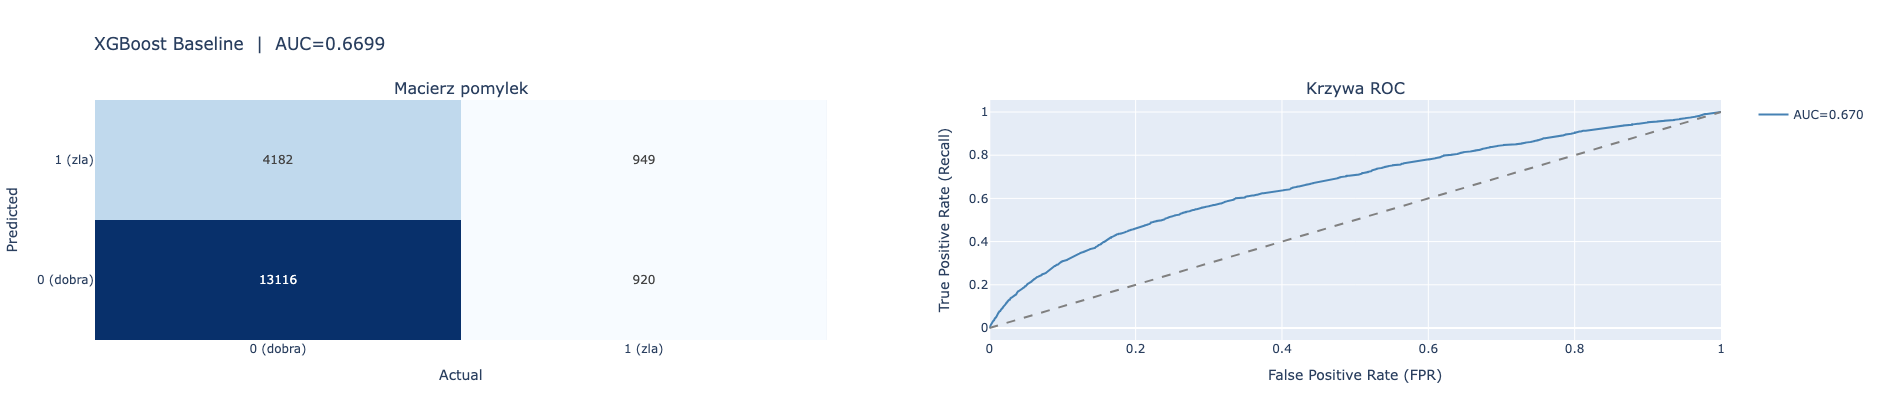

  Precision(1): 0.185
  Recall(1):    0.508
  F1(1):        0.271


In [9]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

def evaluate(model, X_test, y_test, threshold=0.5, name=""):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    auc     = roc_auc_score(y_test, y_proba)
    report  = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cm      = confusion_matrix(y_test, y_pred)

    # Transponujemy: wiersze = Predicted, kolumny = Actual
    cm_T = cm.T
    labels = ["0 (dobra)", "1 (zla)"]

    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=["Macierz pomylek", "Krzywa ROC"])
    fig.add_trace(go.Heatmap(
        z=cm_T, text=cm_T, texttemplate="%{text}",
        x=labels, y=labels,
        colorscale="Blues", showscale=False,
    ), row=1, col=1)
    fig.update_xaxes(title_text="Actual", row=1, col=1)
    fig.update_yaxes(title_text="Predicted", row=1, col=1)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", name=f"AUC={auc:.3f}",
                             line=dict(color="steelblue", width=2)), row=1, col=2)
    fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode="lines",
                             line=dict(dash="dash", color="gray"), showlegend=False),
                  row=1, col=2)
    fig.update_xaxes(title_text="False Positive Rate (FPR)", row=1, col=2)
    fig.update_yaxes(title_text="True Positive Rate (Recall)", row=1, col=2)
    fig.update_layout(title=f"{name}  |  AUC={auc:.4f}", height=420)
    fig.show()

    p1 = report.get("1", {})
    print(f"  Precision(1): {p1.get('precision',0):.3f}")
    print(f"  Recall(1):    {p1.get('recall',0):.3f}")
    print(f"  F1(1):        {p1.get('f1-score',0):.3f}")
    return {"auc": auc, "precision_1": p1.get("precision",0),
            "recall_1": p1.get("recall",0), "f1_1": p1.get("f1-score",0)}

metrics_baseline = evaluate(model_baseline, X_test, y_test, name="XGBoost Baseline")

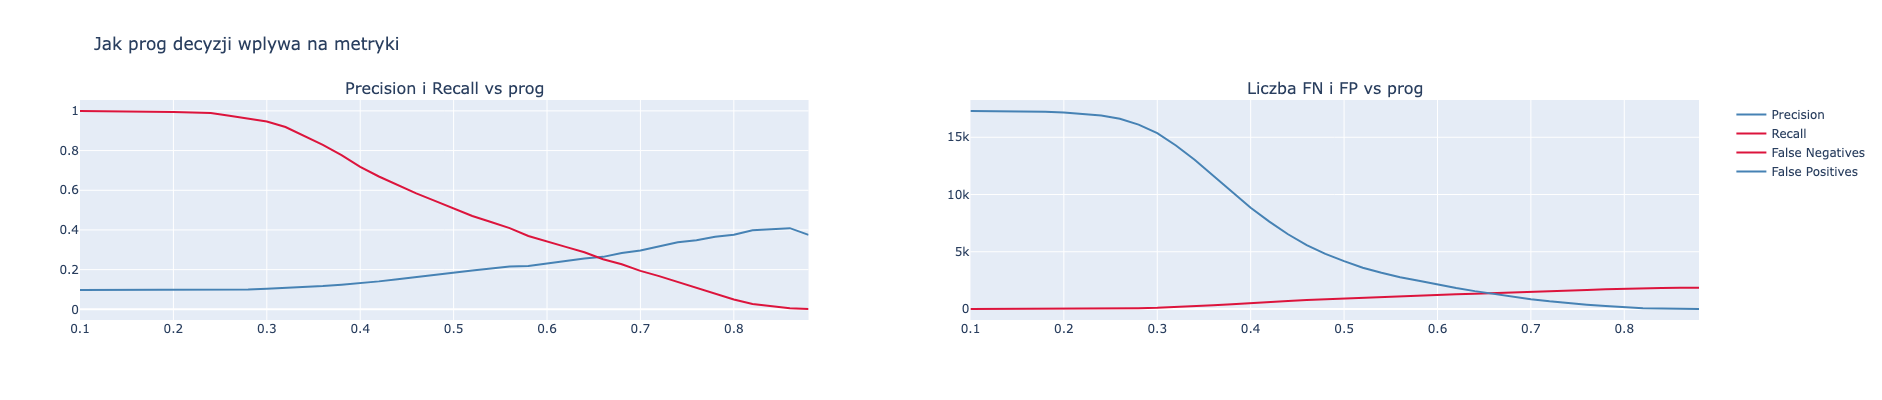

Przy recall >= 0.7: prog=0.40, precision=0.132, FN=527


In [10]:
# Threshold sweep - biznesowo zalezy nam na Recall (nie przegapic zlych zamowien)
thresholds = np.arange(0.1, 0.9, 0.02)
y_proba = model_baseline.predict_proba(X_test)[:, 1]
sweep_rows = []
for t in thresholds:
    pred = (y_proba >= t).astype(int)
    tp = int(((y_test==1) & (pred==1)).sum())
    fp = int(((y_test==0) & (pred==1)).sum())
    fn = int(((y_test==1) & (pred==0)).sum())
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0
    sweep_rows.append({"threshold": t, "precision": p, "recall": r,
                       "fn_count": fn, "fp_count": fp})

df_thresh = pd.DataFrame(sweep_rows)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=["Precision i Recall vs prog",
                                    "Liczba FN i FP vs prog"])
fig.add_trace(go.Scatter(x=df_thresh.threshold, y=df_thresh.precision,
                         name="Precision", line=dict(color="steelblue")), row=1, col=1)
fig.add_trace(go.Scatter(x=df_thresh.threshold, y=df_thresh.recall,
                         name="Recall", line=dict(color="crimson")), row=1, col=1)
fig.add_trace(go.Scatter(x=df_thresh.threshold, y=df_thresh.fn_count,
                         name="False Negatives", line=dict(color="crimson")), row=1, col=2)
fig.add_trace(go.Scatter(x=df_thresh.threshold, y=df_thresh.fp_count,
                         name="False Positives", line=dict(color="steelblue")), row=1, col=2)
fig.update_layout(height=400, title="Jak prog decyzji wplywa na metryki")
fig.show()

TARGET_RECALL = 0.70
optimal = df_thresh[df_thresh.recall >= TARGET_RECALL].iloc[-1]
print(f"Przy recall >= {TARGET_RECALL}: prog={optimal.threshold:.2f}, "
      f"precision={optimal.precision:.3f}, FN={optimal.fn_count:.0f}")

## Checkpoint: zapisz zbior cech

In [11]:
df_train = X_train.copy()
df_train["is_bad_experience"] = y_train.values
df_test  = X_test.copy()
df_test["is_bad_experience"]  = y_test.values

df_train.to_parquet("checkpoints/02_train.parquet", index=False)
df_test.to_parquet( "checkpoints/02_test.parquet",  index=False)

print("Zapisano:")
print(f"  checkpoints/02_train.parquet  {df_train.shape}")
print(f"  checkpoints/02_test.parquet   {df_test.shape}")
print(f"  FEATURE_COLS: {len(FEATURE_COLS)} cech")
print(f"  TARGET: is_bad_experience")

Zapisano:
  checkpoints/02_train.parquet  (76665, 20)
  checkpoints/02_test.parquet   (19167, 20)
  FEATURE_COLS: 19 cech
  TARGET: is_bad_experience


## Feature Importance: SHAP vs XGBoost

**XGBoost gain** - ile razy cecha byla uzywana w podzialach, wazone przez poprawe funkcji straty.
Wada: faworyzuje cechy z duza liczba unikalnych wartosci.

**SHAP (SHapley Additive exPlanations)** - dla kazdego przykladu liczy wklad kazdej cechy
w konkretna predykcje. Mean |SHAP| to sredni bezwzgledny wplyw na wynik modelu.
Zaletia: spojny, interpretowany lokalnie i globalnie.

In [12]:
import shap
import matplotlib.pyplot as plt

explainer   = shap.TreeExplainer(model_baseline)
shap_values = explainer.shap_values(X_test)

df_shap_imp = pd.Series(
    np.abs(shap_values).mean(axis=0), index=FEATURE_COLS
).sort_values()

xgb_scores = model_baseline.get_booster().get_score(importance_type="gain")
df_xgb_imp = pd.Series(xgb_scores).reindex(FEATURE_COLS).fillna(0)
# Normalizuj do [0, 1] dla porownywalnosci
df_xgb_imp = (df_xgb_imp / df_xgb_imp.max()).reindex(df_shap_imp.index)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=["SHAP: mean(|shap|)", "XGBoost: gain (znormalizowany)"])
fig.add_trace(go.Bar(x=df_shap_imp.values, y=df_shap_imp.index,
                     orientation="h", marker_color="steelblue"), row=1, col=1)
fig.add_trace(go.Bar(x=df_xgb_imp.values, y=df_xgb_imp.index,
                     orientation="h", marker_color="crimson"), row=1, col=2)
fig.update_layout(height=550, showlegend=False,
                  title="Feature importance: SHAP vs XGBoost gain")
fig.show()

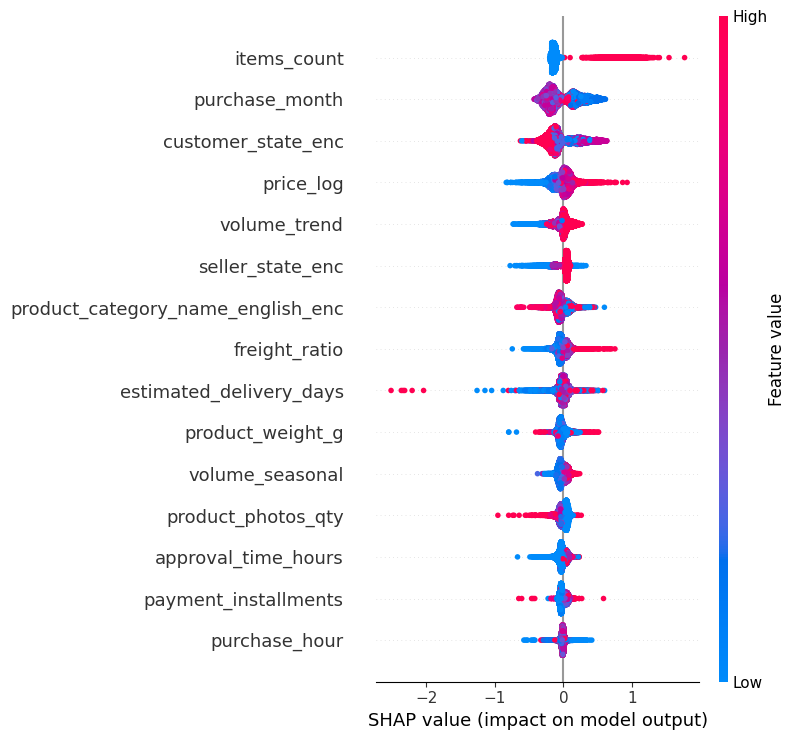

In [13]:
# Beeswarm: kazdy punkt = jedno zamowienie z X_test
# Kolor: czerwony = wysoka wartosc cechy, niebieski = niska
# Pozycja X: ujemna = model widzi mniejsze ryzyko, dodatnia = wieksze ryzyko
shap.summary_plot(shap_values, X_test, plot_type="dot", max_display=15)

## PoC gotowe, czas na produkcjonalizację

Masz dzialajacy model ktory przewiduje czy zamowienie dostanie ocene 1 gwiazdke.
Model dziala lepiej niż coinflip - udowodniliśmy że jest potencjał predykcyjny. Zastanówmy się jak wdrożyć to rozwizanie na produkcję